# Flight path, certified tubes and certification over time

Static figures of one flight: the y-altitude path with the certified part of sampled plans (the tube until its first
violation of the deviation threshold or the ground floor), how long each plan was certified for, and the tube
width in use at each tick. Figures are saved to `figures/` as PDF (TrueType fonts).

In [1]:
import glob, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

from px4_rta_mm_gpr import analysis as rta
rta.use_style()
pd.set_option('display.width', 200, 'display.max_columns', 30)
os.makedirs('figures', exist_ok=True)

In [2]:
# Flight logs to analyse. The example is the latest SITL flight committed with the repository; logs of your own
# runs are written by the node to <workspace>/src/data_analysis/log_files/px4_rta_mm_gpr/<name>.h5
EXAMPLE = 'log_files/sitl/sitl_python_loop_2026-09-28.h5'
WORKSPACE_LOGS = os.path.expanduser('~/Projects/old_projects/OJCSYS27/src/data_analysis/log_files/px4_rta_mm_gpr')
LOGS = [EXAMPLE]
# LOGS = sorted(glob.glob(os.path.join(WORKSPACE_LOGS, '*.h5')))[-5:]   # e.g. your five most recent flights
LOGS

['log_files/sitl/sitl_python_loop_2026-09-28.h5']

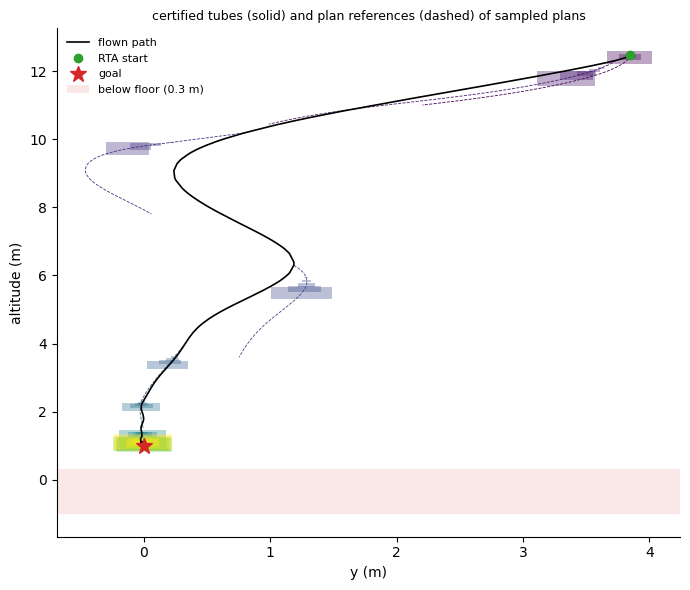

In [3]:
log = rta.load(LOGS[0])
fig, ax = plt.subplots(figsize=(7, 6))
rta.plot_path(log, ax=ax, n_tubes=14)
fig.tight_layout(); fig.savefig('figures/path_tubes.pdf')

## Certified horizon of every plan, and the tube width in use

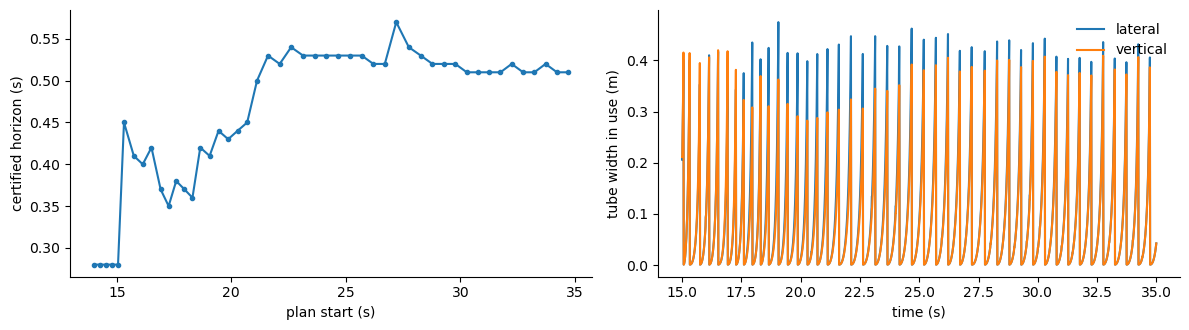

In [4]:
plans = [log.plan(s) for s in log.plan_seqs if not log.plan(s)['warmup']]
t0 = np.array([p['t_start'] for p in plans]); horizon = np.array([rta.certified_rows(p) * p['dt'] for p in plans])
T = log.ticks
fig, axs = plt.subplots(1, 2, figsize=(12, 3.4))
axs[0].plot(t0, horizon, '.-'); axs[0].set_xlabel('plan start (s)'); axs[0].set_ylabel('certified horizon (s)')
axs[1].plot(T['time'], T['tube_py_hi'] - T['tube_py_lo'], label='lateral')
axs[1].plot(T['time'], T['tube_pz_hi'] - T['tube_pz_lo'], label='vertical')
axs[1].set_xlabel('time (s)'); axs[1].set_ylabel('tube width in use (m)'); axs[1].legend(frameon=False)
fig.tight_layout(); fig.savefig('figures/certification.pdf')

## One plan in detail: its tube and reference over time

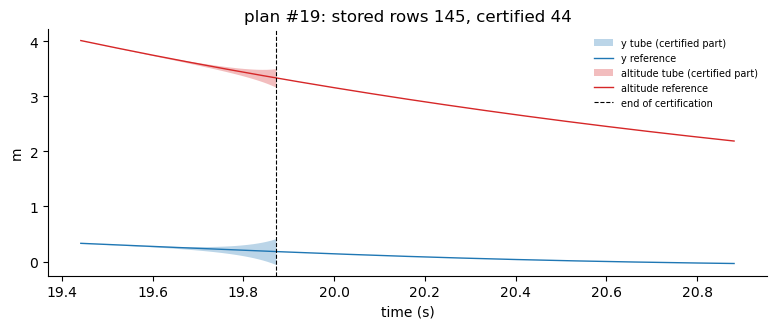

In [5]:
p = plans[len(plans) // 3]
tt = rta.plan_times(p); n = rta.certified_rows(p)
fig, ax = plt.subplots(figsize=(8, 3.4))
for lo, hi, r, lab, c in ((0, 5, 0, 'y', 'tab:blue'), (1, 6, 1, 'altitude', 'tab:red')):
    sgn = -1 if lab == 'altitude' else 1
    ax.fill_between(tt[:n], sgn * p['reachable_tube'][:n, lo], sgn * p['reachable_tube'][:n, hi], color=c, alpha=0.3,
                    lw=0, label=f'{lab} tube (certified part)')
    ax.plot(tt, sgn * p['rollout_ref'][:, r], color=c, lw=1, label=f'{lab} reference')
ax.axvline(tt[n - 1], color='k', ls='--', lw=0.8, label='end of certification')
ax.set_xlabel('time (s)'); ax.set_ylabel('m'); ax.legend(frameon=False, fontsize=7)
ax.set_title(f"plan #{p['seq']}: stored rows {len(tt)}, certified {n}")
fig.tight_layout()